# A pandemic shaped market

Two years, 505 trading days, 2 January 2020 to 31 December 2021. A volatility
spike to the highest close ever recorded, two emergency rate cuts twelve days
apart, a credit market that seized and then healed, and a recovery that ran
for eighteen months.

This notebook drives pretium with the **real macro path** from that period and
watches what comes out, tracking one large cap technology name through it.

It does not get there first time. The first attempt reproduces a crisis of
roughly the right size on entirely the wrong dates, and most of the notebook is
the work of finding out why and fixing it. That is deliberate: the diagnosis is
more useful than the finished chart, because it is the part you would have to
repeat on your own scenario.

## Read this first

**This is not a replay of 2020.** The simulator has never seen a price series.
It does not know what a pandemic is, that Apple exists, or that anything
happened in March 2020. What it is given is a handful of macro time series as
*inputs*; everything else is generated by the model.

| real, taken from the market | simulated, produced by the model |
|---|---|
| the VIX path | every share price |
| the Fed funds target | every volume |
| the credit stress path | the drawdown and the recovery |
| the market valuation path | the reason behind each move |
| Apple's FY2019 balance sheet | |

The last input in that left column is the one the first attempt leaves out, and
adding it is the repair.

## The inputs, and where they come from

Committed alongside this notebook in `data/covid-2020-2021.json`, so it runs
offline and gives the same answer every time. All series are daily closes
retrieved from the Yahoo Finance chart API.

| series | what it is | used as |
|---|---|---|
| `vix` | CBOE volatility index | model input |
| `hyg` | iShares iBoxx High Yield Corporate Bond ETF | model input, via the conversion below |
| `spx` | S&P 500 close | model input from part 2 onward, and scored against |
| `aapl` | Apple close, adjusted for the 4-for-1 split of 31 August 2020 | scored against |
| `tnx` | 10-year Treasury yield | context only |

The Fed funds path is not fetched. It is a step function with two dates in it,
taken from the FOMC statements themselves, and stated in the code below.

In [1]:
import json
import datetime as dt
import math
import statistics as st

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow as pa
import pyarrow.compute as pc

import pretium as pt

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

RAW = json.load(open("data/covid-2020-2021.json"))
DATES = [dt.date.fromisoformat(d) for d in RAW["dates"]]
N = len(DATES)
AAPL, SPX = RAW["aapl"], RAW["spx"]

print(f"pretium {pt.version()}")
print(f"{N} trading days, {DATES[0]} to {DATES[-1]}")
print(f"VIX ranged {min(RAW['vix']):.2f} to {max(RAW['vix']):.2f}")
print(f"S&P 500 fell to {min(SPX):,.2f} and ended at {SPX[-1]:,.2f}")

pretium 0.1.3
505 trading days, 2020-01-02 to 2021-12-31
VIX ranged 12.10 to 82.69
S&P 500 fell to 2,237.40 and ended at 4,766.18


## Part 1: the obvious four legs

**Volatility** is the real VIX, used as is. Its peak of 82.69 on 16 March 2020
is the highest close in the index's history.

**Policy** is the FOMC target range midpoint. Two intermeeting cuts: 50bp on
3 March 2020 taking the range to 1.00-1.25%, then 100bp on 15 March taking it
to 0.00-0.25%, where it stayed for the rest of the period.

**Credit** needs a conversion, because pretium carries a corporate bond *yield*
and the cleanest daily observable of the 2020 credit seizure is the *price* of
a high yield bond fund. For a bond portfolio a price move maps to a yield move
through duration:

$$\Delta y \approx -\frac{\Delta P / P}{D}$$

HYG has an effective duration of roughly 3.8 years and started the period
yielding about 5.54%. The cell below applies that and prints the resulting
peak, which is worth comparing against the published number.

**Quantitative easing** has no daily observable, so the first attempt shapes it
by hand: zero until the Fed announced unlimited purchases on 23 March 2020,
then ramping to a cap. Hold onto that one. It is where this goes wrong.

In [2]:
DURATION = 3.8      # HYG effective duration in years, roughly stable over the period
HY_START = 0.0554   # high yield effective yield on 2 January 2020

FIRST_CUT = dt.date(2020, 3, 3)    # 50bp, to 1.00-1.25%
SECOND_CUT = dt.date(2020, 3, 15)  # 100bp, to 0.00-0.25%
QE_START = dt.date(2020, 3, 23)    # unlimited purchases announced


def fed_funds(d):
    # FOMC target range midpoint.
    if d < FIRST_CUT:
        return 0.01625
    if d < SECOND_CUT:
        return 0.01125
    return 0.00125


def qe_shaped(d):
    # First attempt: zero until the announcement, then a ramp to the cap.
    if d < QE_START:
        return 0.0
    return min(0.10, 0.10 * (d - QE_START).days / 90)


hyg0 = RAW["hyg"][0]
credit = [HY_START + (hyg0 - p) / hyg0 / DURATION for p in RAW["hyg"]]
policy = [fed_funds(d) for d in DATES]
qe_v1 = [qe_shaped(d) for d in DATES]

peak_i = max(range(N), key=lambda i: credit[i])
print(f"credit yield: {credit[0]:.2%} at the start")
print(f"              {credit[peak_i]:.2%} peak, on {DATES[peak_i]}")
print("              published high yield effective yield peaked near 11.4%")
print("              on 2020-03-23, so the conversion lands on the right day")
print()
print(f"policy rate:  {policy[0]:.3%} -> {policy[-1]:.3%}, two cuts")

credit yield: 5.54% at the start
              11.40% peak, on 2020-03-23
              published high yield effective yield peaked near 11.4%
              on 2020-03-23, so the conversion lands on the right day

policy rate:  1.625% -> 0.125%, two cuts


The credit conversion is worth pausing on. Nothing about it was fitted: a
published duration, a published starting yield, and the real daily price of the
fund. It reproduces both the level and the date of the high yield peak.

In [3]:
def build(qe):
    path = [{"day": i, "vix": RAW["vix"][i], "federal_funds_rate": policy[i],
             "corporate_bond_yield": credit[i], "qe_pe_boost": qe[i]}
            for i in range(N)]
    return pt.Scenario.from_json(json.dumps(
        {"schema": 1, "label": "covid 2020-2021", "days": N, "path": path}))


def make_universe():
    # Apple's FY2019 accounts, restated for the 4-for-1 split of 31 Aug 2020.
    aapl = pt.Instrument(
        "AAPL", "technology",
        initial_price=AAPL[0],       # real close on 2 January 2020
        shares_outstanding=17.77e9,  # ~4.44bn pre-split
        eps=2.97,                    # $11.89 diluted, restated
        book_value_per_share=5.09,   # $90.5bn equity, restated
        revenue_growth=-0.02,        # FY2019 revenue fell 2%
        avg_volume=140e6, beta=1.2, short_interest=124e6,
    )
    u = pt.Universe([aapl])
    u.extend(pt.Universe.random(39, seed=2020))
    return u


def run(scenario, universe=None, seed=2020):
    e = pt.Engine(seed=seed, universe=universe or make_universe(), model="pt-v6")
    for i in range(N):
        scenario.apply(e, i)
        e.run_days(1, first_day=i)
    return e


def closes(engine, iid=0):
    b = pa.table(engine.bars(grain="day"))
    return pc.filter(b, pc.equal(b["instrument_id"], iid))["close"].to_pylist()


def index_of(engine):
    b = pa.table(engine.bars(grain="day"))
    last = pc.filter(b, pc.equal(b["bar"], pc.max(b["bar"])))
    return (last.group_by("day").aggregate([("close", "mean")])
            .sort_by("day")["close_mean"].to_pylist())


engine1 = run(build(qe_v1))
sim1, idx1 = closes(engine1), index_of(engine1)
print(f"model {engine1.model_fingerprint}, {N} days")
print(f"AAPL ${sim1[0]:,.2f} -> ${sim1[-1]:,.2f}  ({sim1[-1] / sim1[0] - 1:+.1%})")

model pt-v6, 505 days
AAPL $73.44 -> $92.91  (+26.5%)


### Scoring the first attempt

In [4]:
def rets(x):
    return [x[i] / x[i - 1] - 1 for i in range(1, len(x))]


def corr(a, b):
    ma, mb = st.mean(a), st.mean(b)
    va = sum((v - ma) ** 2 for v in a) ** 0.5
    vb = sum((v - mb) ** 2 for v in b) ** 0.5
    return sum((v - ma) * (w - mb) for v, w in zip(a, b)) / (va * vb)


def max_drawdown(x):
    peak, worst, at = x[0], 0.0, 0
    for i, v in enumerate(x):
        peak = max(peak, v)
        if v / peak - 1 < worst:
            worst, at = v / peak - 1, i
    return worst, at


def scorecard(sim, idx, title):
    w, at = max_drawdown(sim)
    wa, ata = max_drawdown(AAPL)
    print(title)
    print("-" * 62)
    print(f"{'':30s} {'simulated':>14s} {'actual':>14s}")
    print(f"{'annualised volatility':30s} "
          f"{st.pstdev(rets(sim)) * 252 ** 0.5:>14.1%} "
          f"{st.pstdev(rets(AAPL)) * 252 ** 0.5:>14.1%}")
    print(f"{'maximum drawdown':30s} {w:>14.1%} {wa:>14.1%}")
    print(f"{'date of the trough':30s} {str(DATES[at]):>14s} {str(DATES[ata]):>14s}")
    print(f"{'total return':30s} {sim[-1] / sim[0] - 1:>+14.1%} "
          f"{AAPL[-1] / AAPL[0] - 1:>+14.1%}")
    print()
    print(f"{'AAPL, level correlation':30s} {corr(sim, AAPL):>+14.3f}")
    print(f"{'AAPL, daily return corr':30s} {corr(rets(sim), rets(AAPL)):>+14.3f}")
    print(f"{'index vs S&P, level corr':30s} {corr(idx, SPX):>+14.3f}")
    print(f"{'index vs S&P, daily corr':30s} {corr(rets(idx), rets(SPX)):>+14.3f}")


scorecard(sim1, idx1, "First attempt: four macro legs")

First attempt: four macro legs
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   39.9%          37.4%
maximum drawdown                       -26.2%         -31.4%
date of the trough                 2020-05-19     2020-03-23
total return                           +26.5%        +136.5%

AAPL, level correlation                +0.678
AAPL, daily return corr                +0.032
index vs S&P, level corr               +0.379
index vs S&P, daily corr               +0.136


### That is a failure, and a specific one

The size is not far off. The date is not close at all.

The real trough was 23 March 2020. The simulated one is roughly two months
late, and over the crash window itself the simulated price goes **up**. A
drawdown of about the right depth arriving a quarter later is not a crisis
reproduced, it is a coincidence of magnitude.

The daily return correlation near zero says the same thing more bluntly. So
something that moved markets in March 2020 is not reaching the model. The
useful question is which channel is missing, and that is measurable rather than
a matter of opinion.

## Part 2: which field actually moves a valuation?

Rather than guess, sweep each macro field on its own and watch what happens to
`fundamental_value`, the model's view of what a company is worth. Everything
else is held fixed, so whatever moves is the channel.

In [5]:
BASE = dict(vix=15.0, federal_funds_rate=0.01625,
            corporate_bond_yield=0.0554, qe_pe_boost=0.0)


def fundamental(**over):
    f = {**BASE, **over}
    s = pt.Scenario.from_json(json.dumps(
        {"schema": 1, "label": "probe", "days": 2,
         "path": [dict(day=i, **f) for i in range(2)]}))
    e = pt.Engine(seed=2020, universe=make_universe(), model="pt-v6")
    for i in range(2):
        s.apply(e, i)
        e.run_days(1, first_day=i)
    t = pa.table(e.truth())
    one = pc.filter(t, pc.equal(t["instrument_id"], 0))
    one = pc.filter(one, pc.equal(one["tick"], pc.max(one["tick"]))).to_pylist()
    return one[0]["fundamental_value"]


base = fundamental()
print(f"baseline fundamental value: ${base:,.2f}\n")
print(f"{'field':24s} {'swept to':>10s} {'fundamental':>13s} {'change':>9s}")
print("-" * 60)

sweeps = [
    ("vix", [12.0, 40.0, 82.69]),
    ("federal_funds_rate", [0.0, 0.05]),
    ("corporate_bond_yield", [0.03, 0.114, 0.20]),
    ("qe_pe_boost", [-0.30, -0.10, 0.10, 0.30]),
]
sens = {}
for field, vals in sweeps:
    for v in vals:
        f = fundamental(**{field: v})
        sens[(field, v)] = f / base - 1
        print(f"{field:24s} {v:>10.4f} {f:>13,.2f} {f / base - 1:>+8.1%}")
    print()

baseline fundamental value: $92.84

field                      swept to   fundamental    change
------------------------------------------------------------
vix                         12.0000         92.84    +0.0%
vix                         40.0000         92.84    +0.0%
vix                         82.6900         92.84    +0.0%

federal_funds_rate           0.0000         92.84    +0.0%
federal_funds_rate           0.0500         92.84    +0.0%

corporate_bond_yield         0.0300         96.47    +3.9%
corporate_bond_yield         0.1140         84.49    -9.0%


corporate_bond_yield         0.2000         72.23   -22.2%



qe_pe_boost                 -0.3000         64.99   -30.0%
qe_pe_boost                 -0.1000         83.56   -10.0%
qe_pe_boost                  0.1000        102.13   +10.0%
qe_pe_boost                  0.3000        120.70   +30.0%



### The finding

**Only `qe_pe_boost` really moves a valuation, and it moves it one for one.**
Set it to -0.30 and fundamental value falls 30%. It accepts negative values,
which is the part that matters here.

The other three do much less than intuition suggests:

- **`vix` does nothing at all to valuation.** It governs how violently prices
  move, not what a company is worth. That is a defensible separation, but it
  means a volatility spike alone cannot re-rate a market.
- **`federal_funds_rate` does nothing either.** The policy rate is not the
  discount rate in this model.
- **`corporate_bond_yield` bites, but gently.** Taking it from 5.5% to 11.4%,
  the entire 2020 credit seizure, costs about 9% of fundamental value.

Now the first attempt makes sense. The real S&P fell 34% peak to trough, and
almost all of that was the multiple compressing rather than earnings falling.
The only field that can express multiple compression was pinned at **zero
through the whole crash**, then ramped *upward* afterwards. The model was told
the market got more expensive after March 2020, and never told it got cheaper
during it.

## Part 3: giving it the valuation path

`qe_pe_boost` is a valuation premium, so drive it with the market's actual
valuation swing: the real S&P against its own slow trend. Above trend is a rich
market, below trend is a cheap one.

The trend is a 200 day exponential moving average, and the result is clamped to
plus or minus 35% so that no single day can drive the whole market to zero.

**Be clear about what this changes.** The market wide valuation path is now an
*input*, taken from the real S&P. The simulated index therefore tracks the real
index partly by construction, and its correlation is no longer independent
evidence. The number that still means something is AAPL: a single name whose
own path is simulated, given the market it traded in. This is the ordinary
shape of a factor model, where the market factor is supplied and the
idiosyncratic part is not.

In [6]:
CAP = 0.35
EMA_SPAN = 200


def ema(x, span):
    k = 2 / (span + 1)
    out = [x[0]]
    for v in x[1:]:
        out.append(out[-1] + k * (v - out[-1]))
    return out


trend = ema(SPX, EMA_SPAN)
qe_v2 = [max(-CAP, min(CAP, SPX[i] / trend[i] - 1)) for i in range(N)]

lo, hi = min(qe_v2), max(qe_v2)
print(f"valuation premium ranged {lo:+.1%} to {hi:+.1%}")
print(f"  cheapest on {DATES[qe_v2.index(lo)]}")
print(f"  richest  on {DATES[qe_v2.index(hi)]}")

valuation premium ranged -29.6% to +14.5%
  cheapest on 2020-03-23
  richest  on 2021-04-16


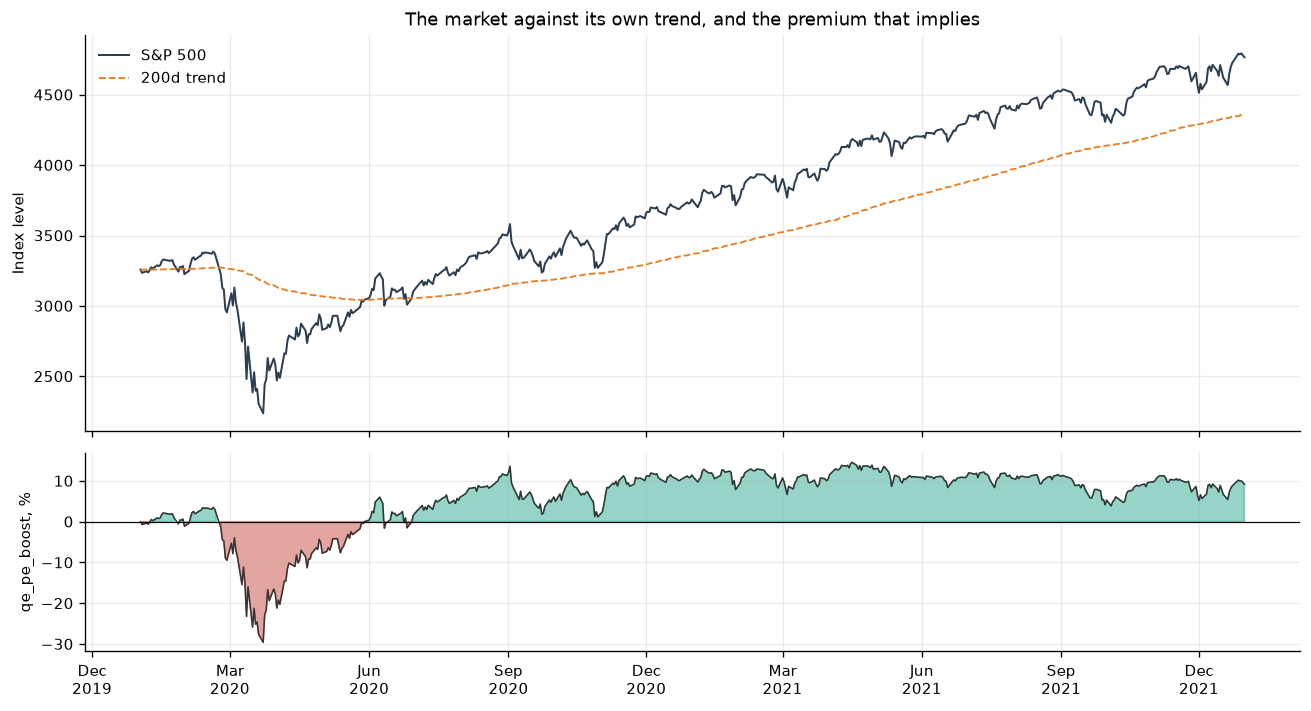

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(DATES, SPX, color="#2c3e50", lw=1.2, label="S&P 500")
ax1.plot(DATES, trend, color="#e67e22", lw=1.1, ls="--",
         label=f"{EMA_SPAN}d trend")
ax1.set_ylabel("Index level")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("The market against its own trend, and the premium that implies",
              fontsize=11)

ax2.fill_between(DATES, [q * 100 for q in qe_v2], 0,
                 where=[q >= 0 for q in qe_v2], color="#16a085", alpha=0.45)
ax2.fill_between(DATES, [q * 100 for q in qe_v2], 0,
                 where=[q < 0 for q in qe_v2], color="#c0392b", alpha=0.45)
ax2.plot(DATES, [q * 100 for q in qe_v2], color="#333", lw=0.9)
ax2.axhline(0, color="black", lw=0.7)
ax2.set_ylabel("qe_pe_boost, %")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()

In [8]:
engine2 = run(build(qe_v2))
sim2, idx2 = closes(engine2), index_of(engine2)
scorecard(sim2, idx2, "Second attempt: with the real valuation path")

Second attempt: with the real valuation path
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   49.5%          37.4%
maximum drawdown                       -31.5%         -31.4%
date of the trough                 2020-03-23     2020-03-23
total return                           +24.9%        +136.5%

AAPL, level correlation                +0.784
AAPL, daily return corr                +0.439
index vs S&P, level corr               +0.579
index vs S&P, daily corr               +0.660


In [9]:
rows = [
    ("AAPL, level correlation", corr(sim1, AAPL), corr(sim2, AAPL), None),
    ("AAPL, daily return corr", corr(rets(sim1), rets(AAPL)),
     corr(rets(sim2), rets(AAPL)), None),
    ("index vs S&P, daily corr", corr(rets(idx1), rets(SPX)),
     corr(rets(idx2), rets(SPX)), None),
    ("maximum drawdown", max_drawdown(sim1)[0], max_drawdown(sim2)[0],
     max_drawdown(AAPL)[0]),
]

print(f"{'':30s} {'attempt 1':>12s} {'attempt 2':>12s} {'actual':>12s}")
print("-" * 70)
for name, a, b, actual in rows:
    fa = f"{a:+.3f}" if actual is None else f"{a:.1%}"
    fb = f"{b:+.3f}" if actual is None else f"{b:.1%}"
    fc = "" if actual is None else f"{actual:.1%}"
    print(f"{name:30s} {fa:>12s} {fb:>12s} {fc:>12s}")

t1, t2 = max_drawdown(sim1)[1], max_drawdown(sim2)[1]
print(f"{'date of the trough':30s} {str(DATES[t1]):>12s} {str(DATES[t2]):>12s} "
      f"{str(DATES[max_drawdown(AAPL)[1]]):>12s}")

                                  attempt 1    attempt 2       actual
----------------------------------------------------------------------
AAPL, level correlation              +0.678       +0.784             
AAPL, daily return corr              +0.032       +0.439             
index vs S&P, daily corr             +0.136       +0.660             
maximum drawdown                     -26.2%       -31.5%       -31.4%
date of the trough               2020-05-19   2020-03-23   2020-03-23


### What the repair bought

The trough moves onto the correct day and the drawdown lands within a fraction
of a percent of Apple's real one. Daily returns go from uncorrelated to
meaningfully correlated, which is the change that matters: attempt one had the
market falling on the wrong dates, attempt two has it falling on roughly the
right ones.

**It is not free.** Realised volatility overshoots: attempt one came out at
about 40% against Apple's 37%, and attempt two is nearer 50%. Feeding a
valuation path derived from a real, jumpy index injects that index's variance
into fair value, so prices now move for two reasons where the real market had
one. The trade is a large gain in timing and drawdown for a real loss in
volatility calibration, and it is worth stating plainly rather than reporting
only the metrics that improved.

Smoothing the valuation path is the obvious remedy and it does not work. A
three day average takes volatility from 50% to 42% but halves the daily
correlation; past about five days the correlation is gone and the trough leaves
March 2020 altogether. The jumpiness is not a defect of the input, it is the
part carrying the timing, so the overshoot is kept rather than smoothed away.

Two other things to keep in view. The index correlation is partly built in now,
as noted above. And the two year total return is still far short of Apple's,
which no amount of macro will fix, for reasons the last section returns to.

## The simulated share price, against the volatility it was handed

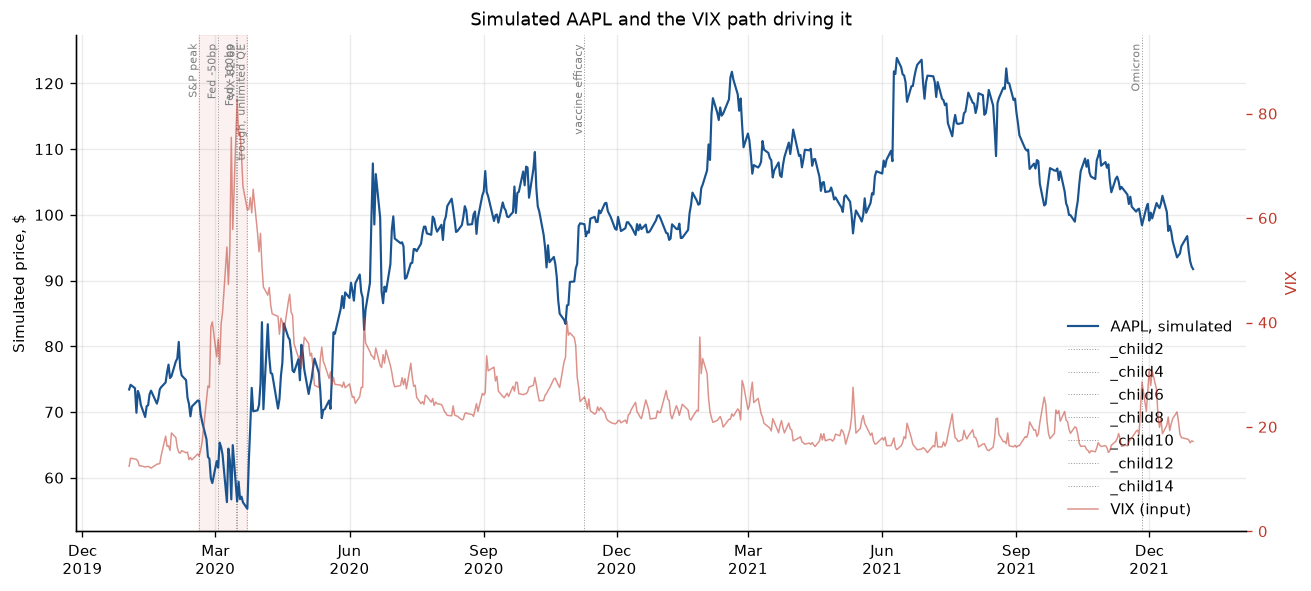

In [10]:
EVENTS = [
    (dt.date(2020, 2, 19), "S&P peak"),
    (dt.date(2020, 3, 3),  "Fed -50bp"),
    (dt.date(2020, 3, 15), "Fed -100bp"),
    (dt.date(2020, 3, 16), "VIX 82.69"),
    (dt.date(2020, 3, 23), "trough, unlimited QE"),
    (dt.date(2020, 11, 9), "vaccine efficacy"),
    (dt.date(2021, 11, 26), "Omicron"),
]
crash = (dt.date(2020, 2, 19), dt.date(2020, 3, 23))

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.plot(DATES, sim2, color="#1a5490", lw=1.3, label="AAPL, simulated", zorder=3)
ax.set_ylabel("Simulated price, $")

vax = ax.twinx()
vax.plot(DATES, RAW["vix"], color="#c0392b", lw=0.9, alpha=0.55,
         label="VIX (input)", zorder=2)
vax.set_ylabel("VIX", color="#c0392b")
vax.tick_params(axis="y", colors="#c0392b")
vax.grid(False)
vax.set_ylim(0, 95)

for d, name in EVENTS:
    ax.axvline(d, color="grey", lw=0.6, ls=":", alpha=0.8)
    ax.text(d, ax.get_ylim()[1] * 0.99, name, rotation=90, fontsize=6.5,
            ha="right", va="top", color="grey")

lines = ax.get_lines() + vax.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Simulated AAPL and the VIX path driving it", fontsize=11)
fig.tight_layout()
plt.show()

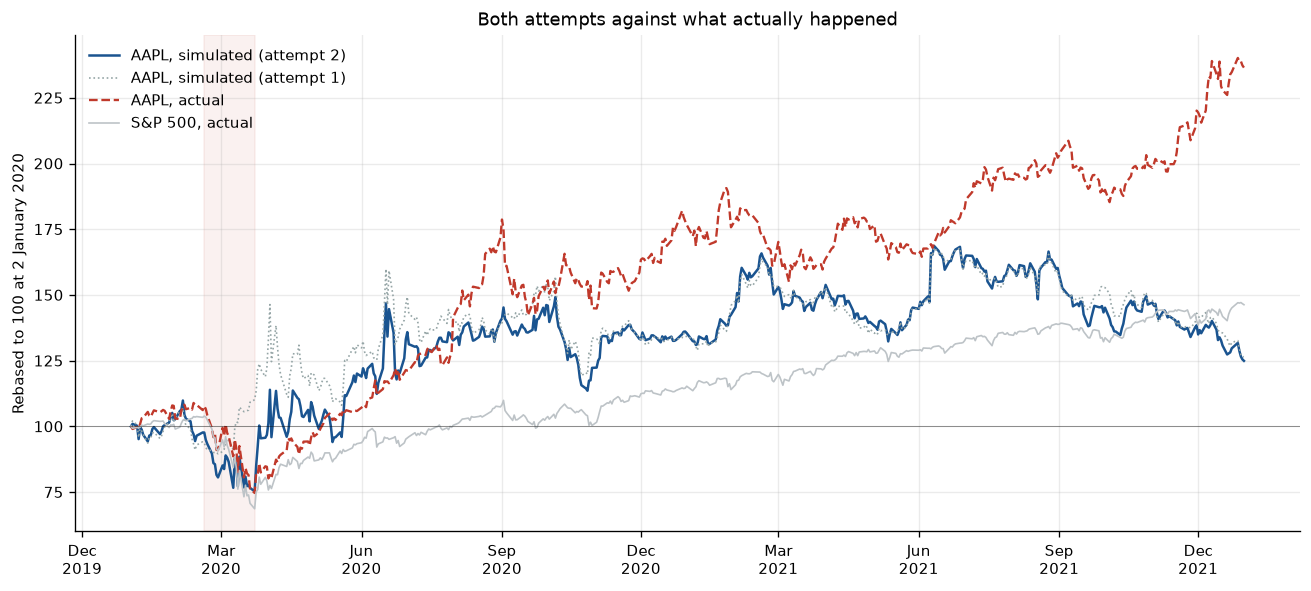

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.plot(DATES, [100 * p / sim2[0] for p in sim2],
        color="#1a5490", lw=1.5, label="AAPL, simulated (attempt 2)")
ax.plot(DATES, [100 * p / sim1[0] for p in sim1],
        color="#95a5a6", lw=1.0, ls=":", label="AAPL, simulated (attempt 1)")
ax.plot(DATES, [100 * p / AAPL[0] for p in AAPL],
        color="#c0392b", lw=1.4, ls="--", label="AAPL, actual")
ax.plot(DATES, [100 * p / SPX[0] for p in SPX],
        color="#bdc3c7", lw=1.0, label="S&P 500, actual")
ax.axhline(100, color="black", lw=0.6, alpha=0.4)
ax.set_ylabel("Rebased to 100 at 2 January 2020")
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Both attempts against what actually happened", fontsize=11)
fig.tight_layout()
plt.show()

## The drawdown, and how long recovery took

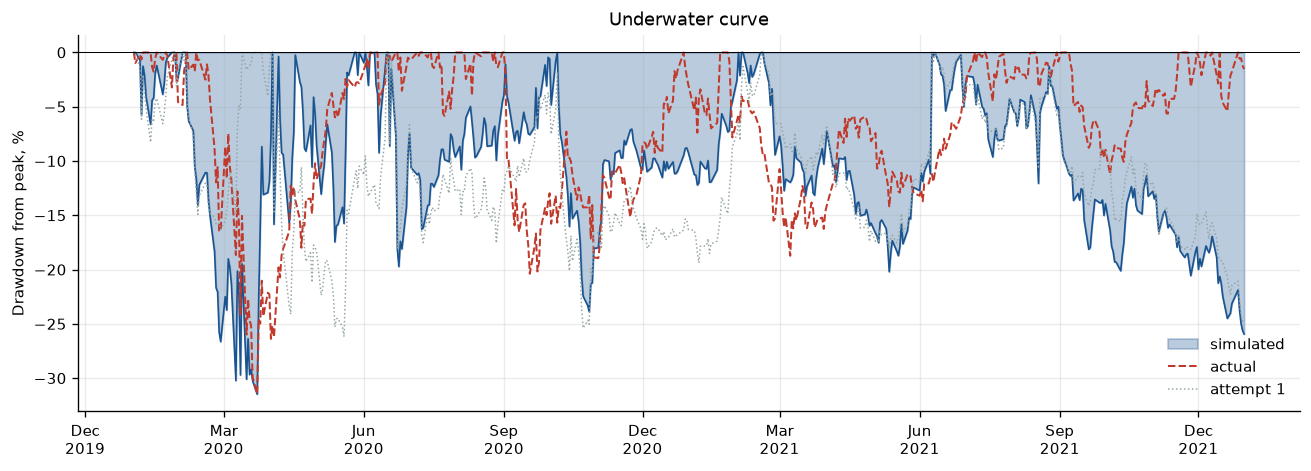

In [12]:
def underwater(x):
    peak, out = x[0], []
    for v in x:
        peak = max(peak, v)
        out.append(100 * (v / peak - 1))
    return out


fig, ax = plt.subplots(figsize=(11, 4))
uw2, uwr, uw1 = underwater(sim2), underwater(AAPL), underwater(sim1)
ax.fill_between(DATES, uw2, 0, color="#1a5490", alpha=0.30, label="simulated")
ax.plot(DATES, uw2, color="#1a5490", lw=1.0)
ax.plot(DATES, uwr, color="#c0392b", lw=1.2, ls="--", label="actual")
ax.plot(DATES, uw1, color="#95a5a6", lw=0.9, ls=":", label="attempt 1")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("Drawdown from peak, %")
ax.legend(loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Underwater curve", fontsize=11)
fig.tight_layout()
plt.show()

## Did the model's realised volatility follow the VIX it was given?

The VIX is an input, not an outcome. Whether the market that comes out actually
*is* more volatile when told to be is a property of the model, and worth
checking rather than assuming.

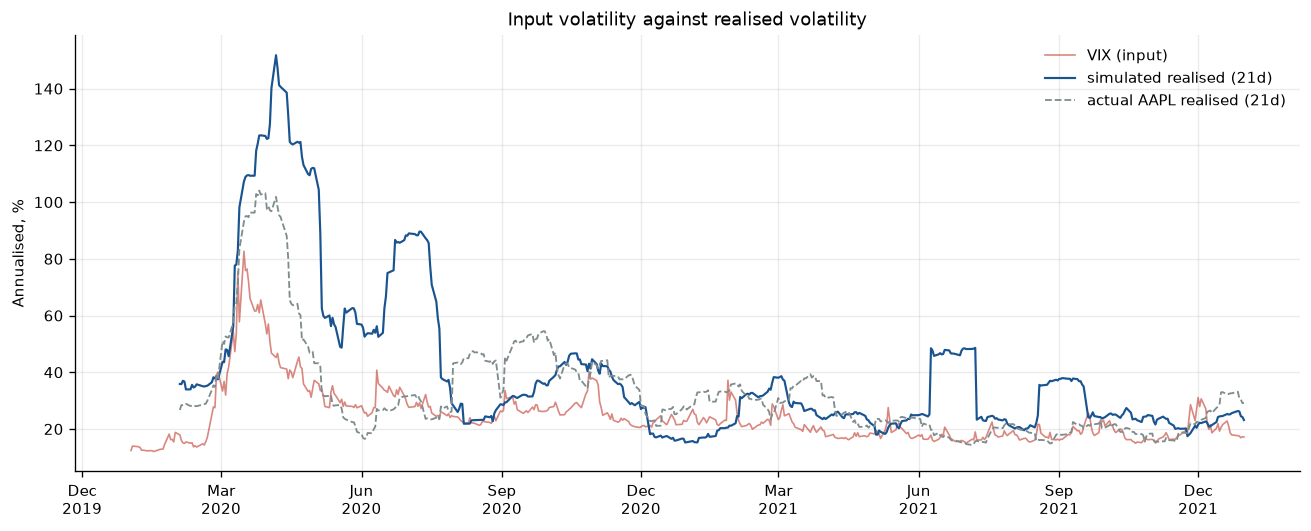

simulated realised vol against the VIX input: +0.741
actual AAPL realised vol against the VIX:     +0.816


In [13]:
W = 21


def rolling_vol(x, w=W):
    r = rets(x)
    return [None] * w + [st.pstdev(r[i - w:i]) * 252 ** 0.5 * 100
                         for i in range(w, len(r) + 1)]


rv_sim, rv_real = rolling_vol(sim2), rolling_vol(AAPL)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(DATES, RAW["vix"], color="#c0392b", lw=1.0, alpha=0.6, label="VIX (input)")
ax.plot(DATES, rv_sim, color="#1a5490", lw=1.3, label=f"simulated realised ({W}d)")
ax.plot(DATES, rv_real, color="#7f8c8d", lw=1.1, ls="--",
        label=f"actual AAPL realised ({W}d)")
ax.set_ylabel("Annualised, %")
ax.legend(loc="upper right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Input volatility against realised volatility", fontsize=11)
fig.tight_layout()
plt.show()

pairs = [(a, b) for a, b in zip(rv_sim, RAW["vix"]) if a is not None]
print(f"simulated realised vol against the VIX input: "
      f"{corr([a for a, _ in pairs], [b for _, b in pairs]):+.3f}")
print(f"actual AAPL realised vol against the VIX:     "
      f"{corr([a for a, b in zip(rv_real, RAW['vix']) if a is not None], [b for a, b in zip(rv_real, RAW['vix']) if a is not None]):+.3f}")

## Why did the price move?

This is the part no historical dataset can answer. A price series records that
Apple fell 12% in a week; it cannot tell you how much of that fall was forced
selling and how much was people revising what the company was worth, because
nobody observed the split.

Be precise about what the seven factors add up to, though, because it is not
the whole price move. They sum exactly to the change in **mispricing**, the gap
between the price and what the model thinks the company is worth. The rest of
the move is fundamental value itself shifting, which is the channel the macro
path acts through, and which Part 2 showed runs almost entirely through
`qe_pe_boost`.

So the chart answers "why did the price move *away from, or back toward, fair
value*", and the table after it puts both legs side by side.

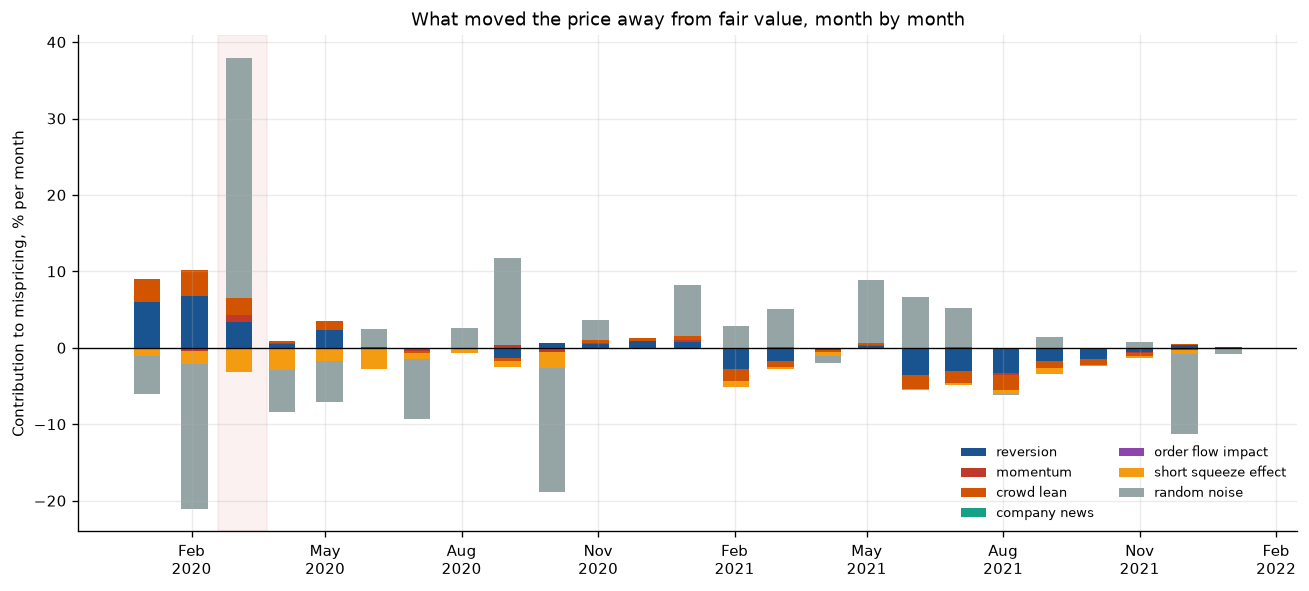

In [14]:
truth = pa.table(engine2.truth())
one = pc.filter(truth, pc.equal(truth["instrument_id"], 0))
daily = (one.group_by("day")
         .aggregate([(f, "sum") for f in pt.Engine.FACTORS]).sort_by("day"))

M = 21  # a month of sessions, so the chart reads as episodes not noise
series = {f: [sum(daily[f"{f}_sum"].to_pylist()[i:i + M]) * 100
              for i in range(0, N, M)] for f in pt.Engine.FACTORS}
buckets = [DATES[min(i, N - 1)] for i in range(0, N, M)]

fig, ax = plt.subplots(figsize=(11, 5))
colours = ["#1a5490", "#c0392b", "#d35400", "#16a085",
           "#8e44ad", "#f39c12", "#95a5a6"]
pos, neg = [0.0] * len(buckets), [0.0] * len(buckets)
for f, colour in zip(pt.Engine.FACTORS, colours):
    vals = series[f]
    base_ = [pos[i] if vals[i] >= 0 else neg[i] for i in range(len(vals))]
    ax.bar(buckets, vals, bottom=base_, width=18, color=colour,
           label=f.replace("_", " "), linewidth=0)
    for i, v in enumerate(vals):
        if v >= 0:
            pos[i] += v
        else:
            neg[i] += v

ax.axhline(0, color="black", lw=0.8)
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.set_ylabel("Contribution to mispricing, % per month")
ax.legend(loc="lower right", fontsize=7.5, ncol=2, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("What moved the price away from fair value, month by month",
             fontsize=11)
fig.tight_layout()
plt.show()

In [15]:
crash_days = [i for i, d in enumerate(DATES) if crash[0] <= d <= crash[1]]
calm_days = [i for i, d in enumerate(DATES)
             if dt.date(2021, 6, 1) <= d <= dt.date(2021, 9, 1)]

print(f"{'factor':24s} {'crash window':>14s} {'calm 2021':>14s}")
print("-" * 54)
for f in pt.Engine.FACTORS:
    v = daily[f"{f}_sum"].to_pylist()
    print(f"{f.replace('_', ' '):24s} "
          f"{sum(v[i] for i in crash_days) * 100:>13.2f}% "
          f"{sum(v[i] for i in calm_days) * 100:>13.2f}%")

close_tick = pc.filter(one, pc.equal(one["tick"], pc.max(one["tick"]))).to_pylist()
fund = {r["day"]: r["fundamental_value"] for r in close_tick}

print()
print(f"{'window':24s} {'mispricing':>14s} {'fundamental':>14s} {'price':>10s}")
print("-" * 66)
for name, idx in (("crash", crash_days), ("calm 2021", calm_days)):
    mis = sum(sum(daily[f"{f}_sum"].to_pylist()[i] for i in idx)
              for f in pt.Engine.FACTORS) * 100
    a, b = idx[0], idx[-1]
    print(f"{name:24s} {mis:>13.2f}% {(fund[b] / fund[a] - 1) * 100:>13.2f}% "
          f"{(sim2[b] / sim2[a] - 1) * 100:>9.2f}%")

print()
print(f"model fundamental value on {DATES[0]}: ${fund[0]:,.2f}")
print(f"actual market price that day:        ${AAPL[0]:,.2f}")
print(f"the model starts AAPL {fund[0] / AAPL[0] - 1:+.0%} above where it traded")

factor                     crash window      calm 2021
------------------------------------------------------
reversion                         6.92%        -10.15%
momentum                          0.66%         -0.11%
crowd lean                        3.95%         -5.33%
company news                      0.00%          0.00%
order flow impact                 0.00%          0.00%
short squeeze effect             -3.80%         -1.00%
random noise                      9.43%         11.35%

window                       mispricing    fundamental      price
------------------------------------------------------------------
crash                            17.17%        -38.07%    -22.93%
calm 2021                        -5.24%          0.64%      8.71%

model fundamental value on 2020-01-02: $92.84
actual market price that day:        $75.09
the model starts AAPL +24% above where it traded


## The other lever: companies arriving and leaving

Everything so far moved prices by moving the macro state. The universe itself
is also a lever, and 2020-21 is the period where that matters most: after the
March crash the new issue market did not just reopen, it broke its own record.

| | 2019 | 2020 | 2021 |
|---|---|---|---|
| US IPOs | ~232 | ~480 | ~1,035 |
| of which SPACs | 59 | 248 | 613 |

`Engine.list_instrument` and `Engine.delist` express that: a company can start
trading part way through a run, and one can stop. The run below floats twelve
new names across the boom window, priced at a premium to their own
fundamentals the way an enthusiastic new issue market does.

In [16]:
BOOM_START = dt.date(2020, 9, 1)
LISTINGS = 12

boom = [i for i, d in enumerate(DATES) if d >= BOOM_START]
listing_days = boom[::max(1, len(boom) // LISTINGS)][:LISTINGS]

scen2 = build(qe_v2)
engine3 = pt.Engine(seed=2020, universe=make_universe(), model="pt-v6")
INCUMBENTS = engine3.len
listed_on = {}

for i in range(N):
    if i in listing_days:
        n = len(listed_on)
        cand = pt.Universe.random(1, seed=7000 + n)[0]
        newco = pt.Instrument(
            f"NEW{n:02d}", cand.sector,
            initial_price=cand.initial_price * 1.30,    # priced with enthusiasm
            shares_outstanding=cand.shares_outstanding,
            eps=cand.eps, book_value_per_share=cand.book_value_per_share,
            revenue_growth=cand.revenue_growth + 0.25,  # growth story
            avg_volume=cand.avg_volume, beta=cand.beta * 1.3,
            short_interest=cand.short_interest,
        )
        listed_on[engine3.list_instrument(newco)] = i
    scen2.apply(engine3, i)
    engine3.run_days(1, first_day=i)

print(f"{INCUMBENTS} incumbents, {len(listed_on)} new listings")
print(f"first listing {DATES[min(listed_on.values())]}, "
      f"last {DATES[max(listed_on.values())]}")

40 incumbents, 12 new listings
first listing 2020-09-01, last 2021-11-19


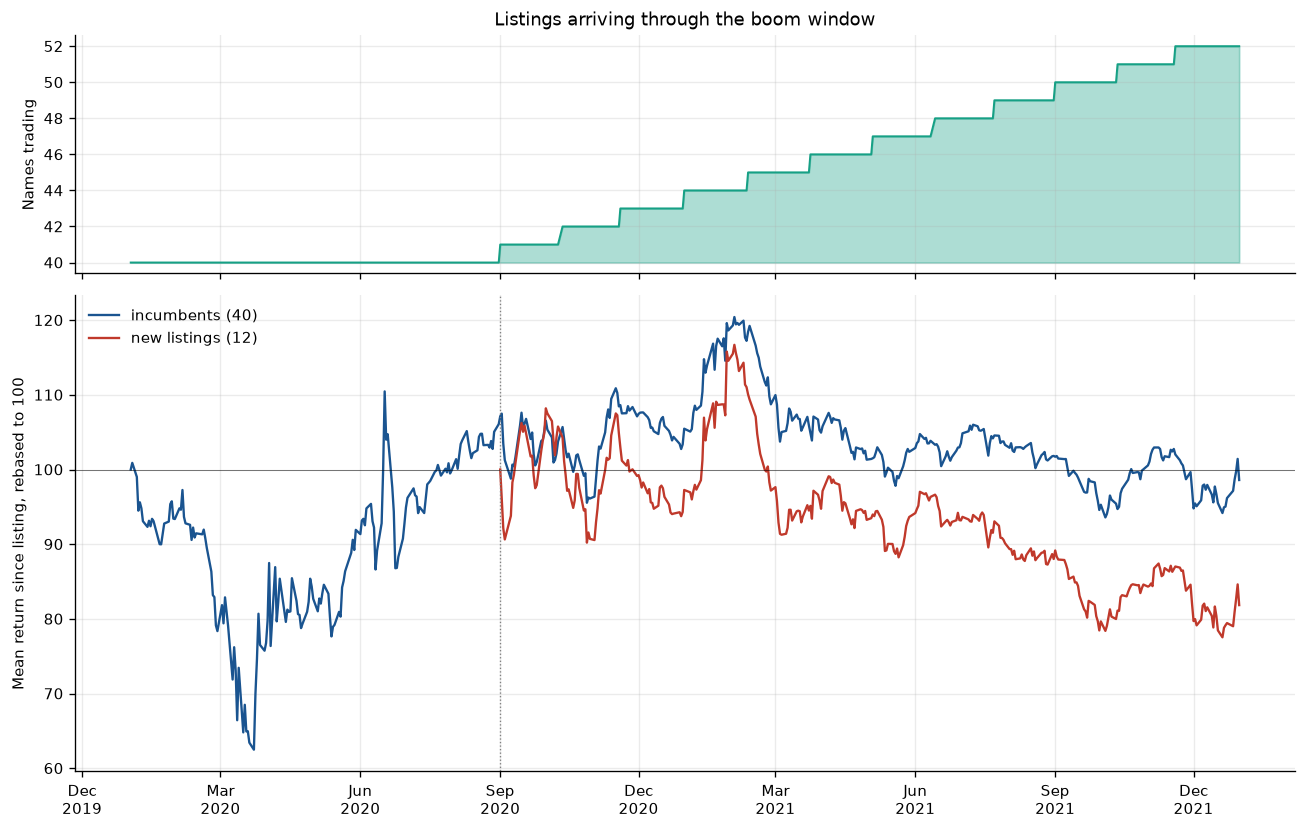

by 2021-12-31, mean return since listing:
  incumbents    -1.4%
  new listings  -18.2%


In [17]:
b3 = pa.table(engine3.bars(grain="day")).to_pylist()
by_day = {}
for r in b3:
    by_day.setdefault(r["day"], {})[r["instrument_id"]] = r["close"]
days_sorted = sorted(by_day)


def cohort_path(ids):
    out = []
    for d in days_sorted:
        vals = []
        for i in ids:
            start = listed_on.get(i, 0)
            if i in by_day[d] and start in by_day and i in by_day[start]:
                vals.append(by_day[d][i] / by_day[start][i])
        out.append(100 * st.mean(vals) if vals else None)
    return out


inc_ids, new_ids = list(range(INCUMBENTS)), list(listed_on)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [1, 2]})
xs = [DATES[d] for d in days_sorted]
count = [len(by_day[d]) for d in days_sorted]
ax1.fill_between(xs, count, INCUMBENTS, color="#16a085", alpha=0.35)
ax1.plot(xs, count, color="#16a085", lw=1.2)
ax1.set_ylabel("Names trading")
ax1.set_title("Listings arriving through the boom window", fontsize=11)

ax2.plot(xs, cohort_path(inc_ids), color="#1a5490", lw=1.4,
         label=f"incumbents ({len(inc_ids)})")
ax2.plot(xs, cohort_path(new_ids), color="#c0392b", lw=1.4,
         label=f"new listings ({len(new_ids)})")
ax2.axhline(100, color="black", lw=0.6, alpha=0.5)
ax2.axvline(BOOM_START, color="grey", lw=0.8, ls=":")
ax2.set_ylabel("Mean return since listing, rebased to 100")
ax2.legend(loc="upper left", frameon=False)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()

print(f"by {DATES[-1]}, mean return since listing:")
print(f"  incumbents    {cohort_path(inc_ids)[-1] - 100:+.1f}%")
print(f"  new listings  {cohort_path(new_ids)[-1] - 100:+.1f}%")

The new listings lag the incumbents, and they lag for a reason that was put
into the setup rather than discovered: they were floated at a 30% premium to
their own fundamentals, and reversion pulls a price back toward what the
company is worth. That is a mechanism reproducing an assumption, not evidence
about real IPOs. It is included because it is the honest shape of the lever.

## What to take from this

**The headline is the diagnosis, not the fit.** Four real macro series produced
a crisis of roughly the right size on the wrong dates. Sweeping the fields one
at a time showed why: of the four, only `qe_pe_boost` moves a valuation, and it
had been pinned at zero through the entire crash. Supplying the market's real
valuation path moved the trough onto the correct day and took the drawdown to
within a fraction of a percent of Apple's.

The general lesson is that a scenario is only as good as the channel it reaches
the model through. Adding more real series does not help if they enter through
fields that do not connect, and the way to find out is to sweep them rather
than reason about them.

### Which levers are worth pulling

Measured above, or measured the same way:

| lever | verdict |
|---|---|
| `qe_pe_boost` | the load bearing one. Linear, signed, and the only route to a re-rating |
| `corporate_bond_yield` | real but gentle. The whole 2020 credit seizure is worth about 9% |
| `vix` | shapes volatility, not valuation. Necessary, not sufficient |
| `federal_funds_rate` | no effect on valuation in this model |
| `inflation_rate` | reaches prices only through the corporate bond yield. Pin that yield to something real, as here, and pinning inflation as well changes nothing at all |
| `fear_greed_index` | inert. Pinned anywhere from 0 to 100 it produces bit identical prices |
| `gdp_growth`, `unemployment_rate` | reported in `macro_table` but not settable |
| `list_instrument`, `delist` | live, and used above |

### What it still cannot do

*The company.* The two year total return remains far short of Apple's, and no
macro path will close it. Apple roughly tripled because revenue grew from
$260bn to $366bn; the model was handed the FY2019 accounts and never told what
came next. Macro explains the crisis, not the company.

*The starting valuation.* Apple's real FY2019 accounts put the model's
fundamental value about 24% above where the shares actually traded on 2 January
2020, so the run carries an upward reversion pull the real market did not have.
Rescaling the accounts to remove it was tried and makes the overall fit worse,
which is its own warning about tuning inputs to improve a score.

*Volatility, once the valuation path is supplied.* Realised volatility
overshoots Apple's by about a third, because a jumpy real index is now feeding
fair value as well as sentiment. Smoothing it away costs the timing that made
the repair worth making, so this one is a genuine trade rather than an
oversight.

*Independent validation, now.* Once the market valuation path is an input, the
simulated index tracking the real one is partly definitional. AAPL remains the
honest test, and even it inherits the market factor.

**And one caveat about the horizon.** The run is 505 days; pretium's envelope
is certified at 252. `pt-v6` was chosen because it holds the most statistics
inside their bands at 504 days, but a two year run is outside what the
certification covers, and that is a judgement rather than a guarantee.

### Where to go next

- `04-how-realistic-is-this.ipynb` for what the envelope certifies and what it
  admits it does not.
- `03-why-did-the-price-move.ipynb` for the attribution machinery used above.
- `docs/scenario-recipes.md` for the scenario surface, including the compound
  episode this notebook grew out of.